# Comparação HRTF pp1: HUTUBS vs COLMAP

**Objetivo**: Comparar as predições HRTF para o mesmo indivíduo (pp1) usando:
1. Mesh original HUTUBS 
2. Reconstrução fotogramétrica (COLMAP)


In [17]:
# 1. Imports e configuração
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trimesh
from pathlib import Path
import pickle
import json
import netCDF4
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

# Paths
project_root = Path("..").resolve()
data_dir = project_root / "data/hutubs"
model_dir = project_root / "ridge_hrtf_output_v2/models"
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

print("Pipeline HRTF: Comparação pp1 HUTUBS vs COLMAP")
print("=" * 60)
print(f"Project root: {project_root}")
print(f"Output dir: {output_dir}")

Pipeline HRTF: Comparação pp1 HUTUBS vs COLMAP
Project root: /home/augusto/projects/PSO-Spatial-Acoustic-Learning
Output dir: output


In [16]:
# 2. Definição do Ridge V2 Extractor
class RidgeV2Extractor:
    """Extrator de medidas antropométricas de meshes 3D"""
    
    def __init__(self):
        self.direct_features = ['x1', 'x2', 'x3', 'L_d5', 'L_d6', 'R_d5', 'R_d6']
        
    def extract_ear(self, vertices, side='left'):
        # Seleciona pontos laterais (5% percentil)
        if side == 'left':
            lateral_mask = vertices[:, 1] < np.percentile(vertices[:, 1], 5)
        else:
            lateral_mask = vertices[:, 1] > np.percentile(vertices[:, 1], 95)
        
        lateral_points = vertices[lateral_mask]
        
        if len(lateral_points) < 100:
            return {'d5': 6.0, 'd6': 3.0, 'points': np.array([]), 'valid': False, 'n_points': 0}
            
        # Filtra pela altura (40% do meio)
        z_min, z_max = vertices[:, 2].min(), vertices[:, 2].max()
        z_middle = (z_min + z_max) / 2
        ear_height_range = (z_max - z_min) * 0.2
        
        ear_mask = (lateral_points[:, 2] > (z_middle - ear_height_range)) & \
                   (lateral_points[:, 2] < (z_middle + ear_height_range))
        
        ear_points = lateral_points[ear_mask]
        
        if len(ear_points) < 50:
            return {'d5': 6.0, 'd6': 3.0, 'points': np.array([]), 'valid': False, 'n_points': 0}
            
        # Remove outliers
        x_center = np.median(ear_points[:, 0])
        x_std = np.std(ear_points[:, 0])
        x_mask = np.abs(ear_points[:, 0] - x_center) < (2 * x_std)
        ear_points = ear_points[x_mask]
        
        # Calcula dimensões
        ear_height = ear_points[:, 2].max() - ear_points[:, 2].min()
        ear_width = ear_points[:, 0].max() - ear_points[:, 0].min()
        
        return {
            'd5': ear_height / 10,  # mm para cm
            'd6': ear_width / 10,
            'points': ear_points,
            'valid': True,
            'n_points': len(ear_points)
        }
    
    def extract_head(self, vertices):
        z_threshold = np.percentile(vertices[:, 2], 30)
        head_vertices = vertices[vertices[:, 2] > z_threshold]
        
        if len(head_vertices) < 1000:
            return {'x1': 15.0, 'x2': 20.0, 'x3': 18.0, 'valid': False}
        
        # Calcula dimensões em cm
        x1 = (head_vertices[:, 1].max() - head_vertices[:, 1].min()) / 10
        x2 = (head_vertices[:, 2].max() - head_vertices[:, 2].min()) / 10
        x3 = (head_vertices[:, 0].max() - head_vertices[:, 0].min()) / 10
        
        return {'x1': x1, 'x2': x2, 'x3': x3, 'valid': True}
    
    def extract_measurements(self, vertices, name="mesh"):
        if np.max(np.abs(vertices)) < 10:
            vertices = vertices * 1000
            
        print(f"\nExtraindo medidas de: {name}")
        print(f"  Vértices: {len(vertices):,}")
        print(f"  Bounds: X[{vertices[:,0].min():.1f}, {vertices[:,0].max():.1f}] mm")
        
        # Extrai medidas
        left_ear = self.extract_ear(vertices, 'left')
        right_ear = self.extract_ear(vertices, 'right')
        head = self.extract_head(vertices)
        
        print(f"  Cabeça: x1={head['x1']:.1f}, x2={head['x2']:.1f}, x3={head['x3']:.1f} cm")
        print(f"  Orelha esq: d5={left_ear['d5']:.1f}, d6={left_ear['d6']:.1f} cm ({left_ear['n_points']} pontos)")
        print(f"  Orelha dir: d5={right_ear['d5']:.1f}, d6={right_ear['d6']:.1f} cm ({right_ear['n_points']} pontos)")
        
        return {
            'x1': head['x1'],
            'x2': head['x2'], 
            'x3': head['x3'],
            'L_d5': left_ear['d5'],
            'L_d6': left_ear['d6'],
            'R_d5': right_ear['d5'],
            'R_d6': right_ear['d6'],
            'left_ear_points': left_ear['n_points'],
            'right_ear_points': right_ear['n_points'],
            'valid': left_ear['valid'] and right_ear['valid'] and head['valid'],
            '_left_ear': left_ear['points'],
            '_right_ear': right_ear['points'],
            '_vertices': vertices
        }

extractor = RidgeV2Extractor()
print("\n Ridge V2 Extractor criado!")


 Ridge V2 Extractor criado!


In [15]:
# 3. Sistema de Derivação de Features
class FeatureDerivation:
    """Sistema para derivar features faltantes"""
    
    def __init__(self):
        # Proporções validadas
        self.proportions = {
            'd1': {'base': 'd5', 'ratio': 0.296},
            'd2': {'base': 'd5', 'ratio': 0.162},
            'd3': {'base': 'd5', 'ratio': 0.481},
            'd4': {'base': 'd5', 'ratio': 0.635},
            'd7': {'base': 'd6', 'ratio': 0.267},
            'd8': {'base': 'd6', 'ratio': 0.472}
        }
        
        # Parâmetros estatísticos
        self.statistical_params = {
            'd9': (0.86, 1.47, 1.19, 0.13),
            'd10': (0.18, 0.47, 0.31, 0.06),
            'theta1': (0.42, 23.86, 10.42, 5.05),
            'theta2': (7.87, 48.43, 25.33, 7.87)
        }
        
        # Offsets da cabeça
        self.head_offsets = {'x4': 0.018, 'x5': 0.025}
        
        # Medidas do corpo
        self.body_measurements = {
            'x6': 15.5, 'x7': 60.0, 'x8': 35.0, 'x9': 17.0,
            'x12': 14.0, 'x14': 11.0, 'x16': 56.0, 'x17': 39.0
        }
    
    def create_hrtf_features(self, measurements, ear='L'):
        """Cria features completas para predição HRTF"""
        # Features base
        features = {
            'x1': measurements['x1'],
            'x2': measurements['x2'],
            'x3': measurements['x3'],
            'x4': measurements['x1'] * self.head_offsets['x4'],
            'x5': measurements['x1'] * self.head_offsets['x5']
        }
        
        # Adiciona medidas do corpo
        for k, v in self.body_measurements.items():
            features[k] = v
        
        # Parâmetros da orelha específica
        prefix = 'L_' if ear == 'L' else 'R_'
        ear_d5 = measurements[f'{prefix}d5']
        ear_d6 = measurements[f'{prefix}d6']
        
        # Features diretas da orelha
        features['d5'] = ear_d5
        features['d6'] = ear_d6
        
        # Deriva proporções
        for num in ['1', '2', '3', '4', '7', '8']:
            config = self.proportions[f'd{num}']
            base_val = ear_d5 if config['base'] == 'd5' else ear_d6
            features[f'd{num}'] = base_val * config['ratio']
        
        # Estatísticas
        np.random.seed(42)
        for feat, (min_val, max_val, mean_val, std_val) in self.statistical_params.items():
            q1 = mean_val - 0.675 * std_val
            q3 = mean_val + 0.675 * std_val
            features[feat] = np.random.uniform(max(min_val, q1), min(max_val, q3))
        
        # Calcula áreas
        features['area_cavum'] = features['d1'] * features['d3'] / 2
        features['area_cymba'] = features['d2'] * features['d3'] / 2
        features['area_fossa'] = features['d4'] * features['d6'] / 2
        features['area_pinna'] = features['d5'] * features['d6'] / 2
        features['area_intertragal'] = features['d7'] * (features['d1'] + features['d3']) / 2
        
        return features

derivation = FeatureDerivation()
print("Sistema de derivação criado!")

Sistema de derivação criado!


In [14]:
# 4. Carregamento dos Modelos e HRTF real

# Constantes HRTF
FS = 44100
TGT_FREQS = np.linspace(1000, 12000, 64)
POS_TGT = [(0,0), (40,0), (320,0), (0,30), (0,-30)]

print("Carregando modelos pré-treinados...")
models = {}

for ear in [0, 1]:
    for pos in range(5):
        model_path = model_dir / f"ridge_ear{ear}_pos{pos}.pkl"
        if model_path.exists():
            with open(model_path, 'rb') as f:
                models[(ear, pos)] = pickle.load(f)

print(f"{len(models)} modelos carregados")

# Carrega HRTF real do pp1
print("\nCarregando HRTF real do pp1...")
sofa_path = data_dir / "pp1_HRIRs_measured.sofa"
hrtf_real = {}

try:
    ds = netCDF4.Dataset(str(sofa_path))
    ir = ds["Data.IR"][:]
    pos = ds["SourcePosition"][:, :2]
    
    # Calcula FFT
    orig_f = np.fft.rfftfreq(ir.shape[-1], 1/FS)
    mask = (orig_f >= 1000) & (orig_f <= 12000)
    band_f = orig_f[mask]
    
    # Encontra índices das posições alvo
    idx_map = [np.argmin(np.sum((pos - p)**2, axis=1)) for p in POS_TGT]
    
    # Processa orelha esquerda
    mag = np.abs(np.fft.rfft(ir[:, 0, :], axis=-1)) + 1e-10
    mag_db = 20 * np.log10(mag[:, mask])
    
    for k, pidx in enumerate(idx_map):
        hrtf_real[k] = np.interp(TGT_FREQS, band_f, mag_db[pidx]).astype(np.float32)
    
    ds.close()
    print(f"HRTF real carregado para {len(hrtf_real)} posições")
    
except Exception as e:
    print(f"Erro ao carregar HRTF: {e}")

Carregando modelos pré-treinados...
10 modelos carregados

Carregando HRTF real do pp1...
HRTF real carregado para 5 posições


In [5]:
# 5. Carregamento e Análise das Meshes

print("\nCarregando meshes...")
print("=" * 60)

# HUTUBS pp1
hutubs_mesh = trimesh.load(data_dir / "meshes/pp1_3DheadMesh.ply")
hutubs_v = np.array(hutubs_mesh.vertices)
hutubs_measurements = extractor.extract_measurements(hutubs_v, "HUTUBS pp1")

# COLMAP pp1
print("\n" + "-" * 60)
photo_mesh = trimesh.load(project_root / "blender/head1_recons_scaled_rotated.ply")
photo_v = np.array(photo_mesh.vertices)
photo_measurements = extractor.extract_measurements(photo_v, "Fotogrametria pp1 (COLMAP)")

print("\n" + "=" * 60)
print(f"DENSIDADE: Fotogrametria tem {len(photo_v)/len(hutubs_v):.1f}x mais vértices")
print(f"ORELHAS: HUTUBS detectou {hutubs_measurements['left_ear_points'] + hutubs_measurements['right_ear_points']:,} pontos")
print(f"ORELHAS: Fotogrametria detectou {photo_measurements['left_ear_points'] + photo_measurements['right_ear_points']:,} pontos")


Carregando meshes...

Extraindo medidas de: HUTUBS pp1
  Vértices: 141,538
  Bounds: X[-97.1, 124.5] mm
  Cabeça: x1=19.0, x2=16.8, x3=22.2 cm
  Orelha esq: d5=5.0, d6=2.8 cm (6259 pontos)
  Orelha dir: d5=4.8, d6=2.8 cm (6170 pontos)

------------------------------------------------------------

Extraindo medidas de: Fotogrametria pp1 (COLMAP)
  Vértices: 284,147
  Bounds: X[-101.6, 124.4] mm
  Cabeça: x1=19.3, x2=15.9, x3=22.5 cm
  Orelha esq: d5=9.9, d6=6.1 cm (10968 pontos)
  Orelha dir: d5=5.1, d6=2.6 cm (13252 pontos)

DENSIDADE: Fotogrametria tem 2.0x mais vértices
ORELHAS: HUTUBS detectou 12,429 pontos
ORELHAS: Fotogrametria detectou 24,220 pontos


In [6]:
# 6. Comparação com Ground Truth

ground_truth = pd.read_csv(data_dir / "AntrhopometricMeasures.csv")
ground_truth.columns = [c.strip() for c in ground_truth.columns]
pp1_gt = ground_truth[ground_truth['SubjectID'] == 1].iloc[0]

print("\n" + "=" * 80)
print("COMPARAÇÃO DE MEDIDAS ANTROPOMÉTRICAS")
print("=" * 80)
print(f"\n{'Medida':<10} {'Ground Truth':>12} {'HUTUBS':>12} {'Fotogrametria':>14} {'Erro HUTUBS':>12} {'Erro Foto':>10}")
print("-" * 80)

features = ['x1', 'x2', 'x3', 'L_d5', 'L_d6', 'R_d5', 'R_d6']
results = []

for feat in features:
    gt_val = pp1_gt[feat]
    hutubs_val = hutubs_measurements[feat]
    photo_val = photo_measurements[feat]
    
    error_hutubs = abs(hutubs_val - gt_val) / gt_val * 100
    error_photo = abs(photo_val - gt_val) / gt_val * 100
    
    results.append({
        'Feature': feat,
        'GT': gt_val,
        'HUTUBS': hutubs_val,
        'Photo': photo_val,
        'Error_HUTUBS': error_hutubs,
        'Error_Photo': error_photo
    })
    
    print(f"{feat:<10} {gt_val:>12.2f} {hutubs_val:>12.2f} {photo_val:>14.2f} {error_hutubs:>11.1f}% {error_photo:>9.1f}%")

df_results = pd.DataFrame(results)
print("-" * 80)
print(f"{'MÉDIA':<10} {'':>12} {'':>12} {'':>14} {df_results['Error_HUTUBS'].mean():>11.1f}% {df_results['Error_Photo'].mean():>9.1f}%")


COMPARAÇÃO DE MEDIDAS ANTROPOMÉTRICAS

Medida     Ground Truth       HUTUBS  Fotogrametria  Erro HUTUBS  Erro Foto
--------------------------------------------------------------------------------
x1                14.81        18.99          19.35        28.2%      30.7%
x2                21.55        16.76          15.90        22.2%      26.2%
x3                18.73        22.16          22.54        18.3%      20.3%
L_d5               5.99         5.01           9.89        16.4%      65.0%
L_d6               3.24         2.84           6.15        12.4%      89.7%
R_d5               6.01         4.80           5.07        20.2%      15.6%
R_d6               3.18         2.77           2.59        13.0%      18.7%
--------------------------------------------------------------------------------
MÉDIA                                                      18.7%      38.0%


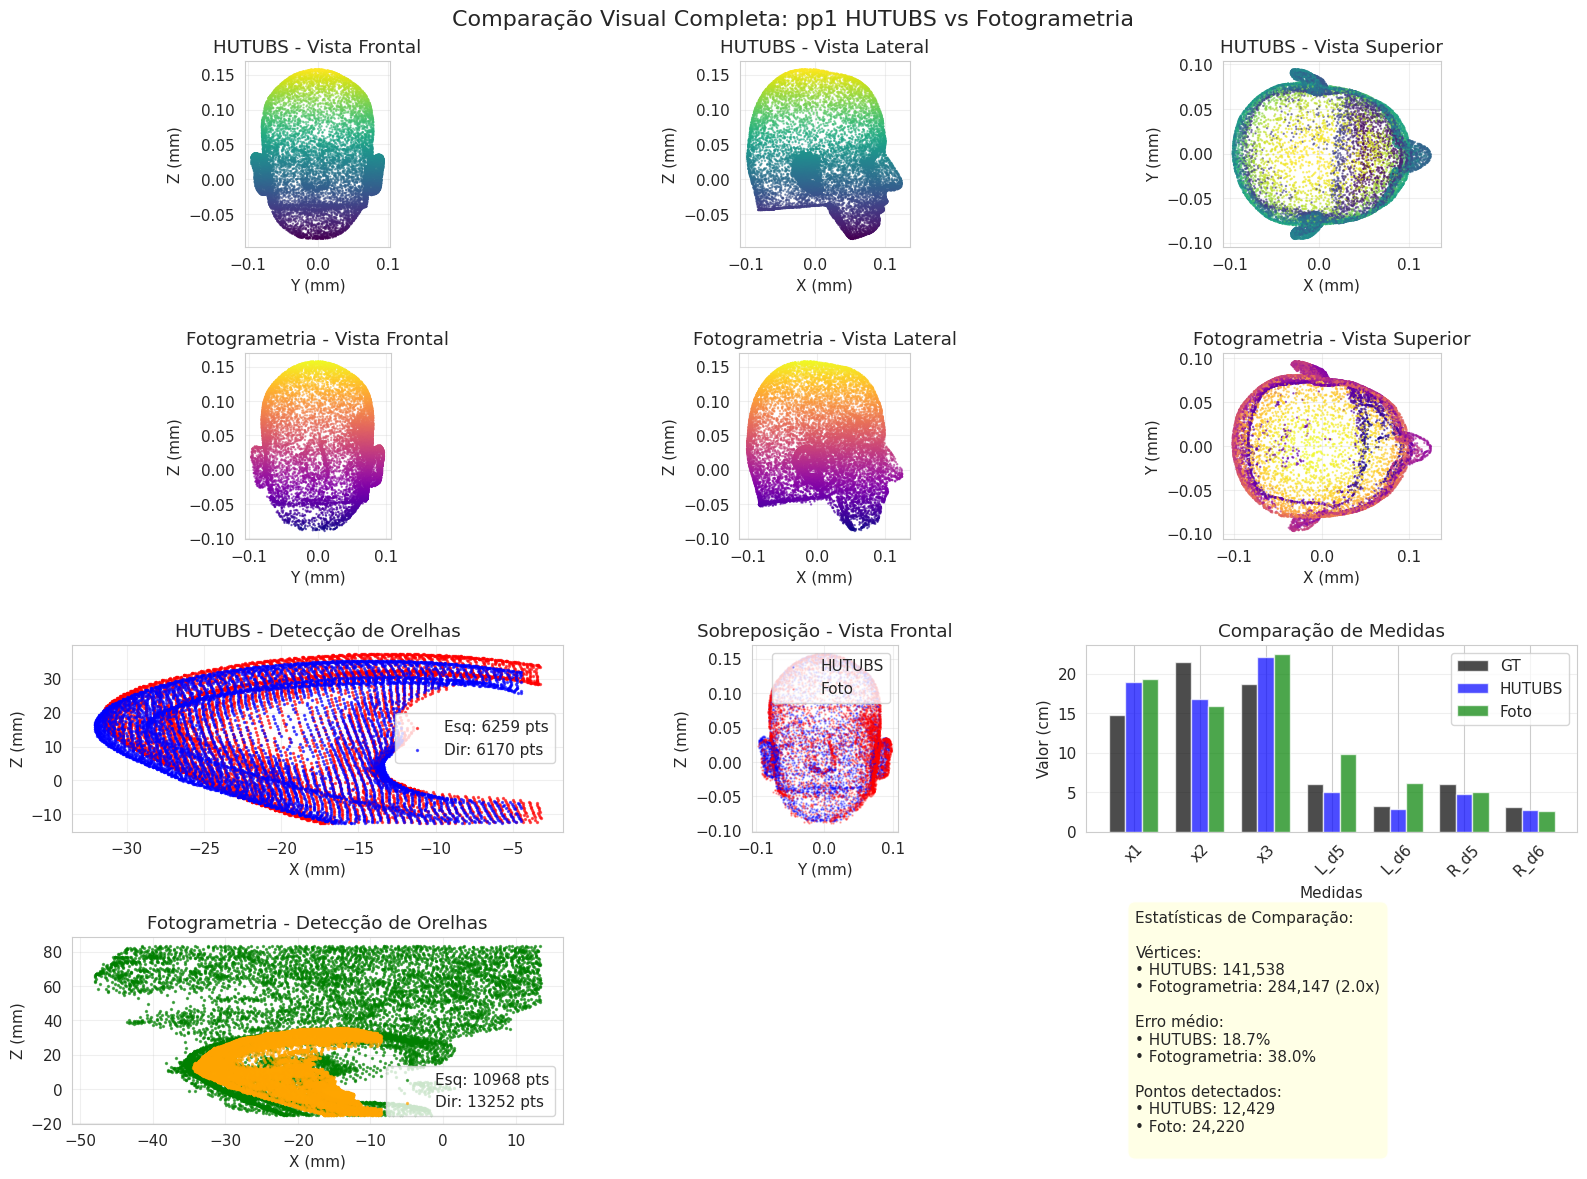

In [7]:
# 7. Visualização Comparativa das Meshes

fig = plt.figure(figsize=(16, 12))

# Função para plotar mesh
def plot_mesh_views(vertices, row_start, color_map, title_prefix):
    # Amostra pontos
    n_sample = min(15000, len(vertices))
    idx = np.random.choice(len(vertices), n_sample, replace=False)
    v_sample = vertices[idx]
    
    # Vista frontal
    ax = plt.subplot(4, 3, row_start)
    ax.scatter(v_sample[:, 1], v_sample[:, 2], c=v_sample[:, 2], cmap=color_map, s=0.5, alpha=0.6)
    ax.set_title(f'{title_prefix} - Vista Frontal')
    ax.set_xlabel('Y (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Vista lateral
    ax = plt.subplot(4, 3, row_start + 1)
    ax.scatter(v_sample[:, 0], v_sample[:, 2], c=v_sample[:, 2], cmap=color_map, s=0.5, alpha=0.6)
    ax.set_title(f'{title_prefix} - Vista Lateral')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Vista superior
    ax = plt.subplot(4, 3, row_start + 2)
    ax.scatter(v_sample[:, 0], v_sample[:, 1], c=v_sample[:, 2], cmap=color_map, s=0.5, alpha=0.6)
    ax.set_title(f'{title_prefix} - Vista Superior')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Plota HUTUBS
plot_mesh_views(hutubs_v, 1, 'viridis', 'HUTUBS')

# Plota Fotogrametria
plot_mesh_views(photo_v, 4, 'plasma', 'Fotogrametria')

# Detecção de orelhas - HUTUBS
ax = plt.subplot(4, 3, 7)
if len(hutubs_measurements['_left_ear']) > 0:
    ear = hutubs_measurements['_left_ear']
    ax.scatter(ear[:, 0], ear[:, 2], c='red', s=2, alpha=0.6, label=f'Esq: {len(ear)} pts')
if len(hutubs_measurements['_right_ear']) > 0:
    ear = hutubs_measurements['_right_ear']
    ax.scatter(ear[:, 0], ear[:, 2], c='blue', s=2, alpha=0.6, label=f'Dir: {len(ear)} pts')
ax.set_title('HUTUBS - Detecção de Orelhas')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Z (mm)')
ax.legend()
ax.grid(True, alpha=0.3)

# Detecção de orelhas - Fotogrametria
ax = plt.subplot(4, 3, 10)
if len(photo_measurements['_left_ear']) > 0:
    ear = photo_measurements['_left_ear']
    ax.scatter(ear[:, 0], ear[:, 2], c='green', s=2, alpha=0.6, label=f'Esq: {len(ear)} pts')
if len(photo_measurements['_right_ear']) > 0:
    ear = photo_measurements['_right_ear']
    ax.scatter(ear[:, 0], ear[:, 2], c='orange', s=2, alpha=0.6, label=f'Dir: {len(ear)} pts')
ax.set_title('Fotogrametria - Detecção de Orelhas')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Z (mm)')
ax.legend()
ax.grid(True, alpha=0.3)

# Sobreposição frontal
ax = plt.subplot(4, 3, 8)
n_sample = 5000
idx_h = np.random.choice(len(hutubs_v), n_sample, replace=False)
idx_p = np.random.choice(len(photo_v), n_sample, replace=False)
ax.scatter(hutubs_v[idx_h, 1], hutubs_v[idx_h, 2], c='blue', s=0.5, alpha=0.3, label='HUTUBS')
ax.scatter(photo_v[idx_p, 1], photo_v[idx_p, 2], c='red', s=0.5, alpha=0.3, label='Foto')
ax.set_title('Sobreposição - Vista Frontal')
ax.set_xlabel('Y (mm)')
ax.set_ylabel('Z (mm)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Comparação de medidas
ax = plt.subplot(4, 3, 9)
x = np.arange(len(features))
width = 0.25
ax.bar(x - width, [pp1_gt[f] for f in features], width, label='GT', color='black', alpha=0.7)
ax.bar(x, [hutubs_measurements[f] for f in features], width, label='HUTUBS', color='blue', alpha=0.7)
ax.bar(x + width, [photo_measurements[f] for f in features], width, label='Foto', color='green', alpha=0.7)
ax.set_xlabel('Medidas')
ax.set_ylabel('Valor (cm)')
ax.set_title('Comparação de Medidas')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Estatísticas
ax = plt.subplot(4, 3, 12)
ax.axis('off')
stats_text = f"""Estatísticas de Comparação:

Vértices:
• HUTUBS: {len(hutubs_v):,}
• Fotogrametria: {len(photo_v):,} ({len(photo_v)/len(hutubs_v):.1f}x)

Erro médio:
• HUTUBS: {df_results['Error_HUTUBS'].mean():.1f}%
• Fotogrametria: {df_results['Error_Photo'].mean():.1f}%

Pontos detectados:
• HUTUBS: {hutubs_measurements['left_ear_points'] + hutubs_measurements['right_ear_points']:,}
• Foto: {photo_measurements['left_ear_points'] + photo_measurements['right_ear_points']:,}
"""
ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Comparação Visual Completa: pp1 HUTUBS vs Fotogrametria', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'pp1_visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 8. Predição HRTF e Cálculo de R²

# Define ordem das features
feature_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x16', 'd1', 'd2', 'd3', 'd4', 'd5', 
                'd6', 'd7', 'd8', 'd9', 'd10', 'theta1', 'theta2', 'area_cavum', 
                'area_cymba', 'area_fossa', 'area_pinna', 'area_intertragal']

# Prepara features
hutubs_features = derivation.create_hrtf_features(hutubs_measurements, 'L')
photo_features = derivation.create_hrtf_features(photo_measurements, 'L')

hutubs_X = np.array([hutubs_features[f] for f in feature_cols])
photo_X = np.array([photo_features[f] for f in feature_cols])

print("\n" + "=" * 60)
print("PREDIÇÃO HRTF E CÁLCULO DE R²")
print("=" * 60)

# Função para calcular R²
def r2_correlation(y_true, y_pred):
    if len(y_true) == 0 or len(y_pred) == 0:
        return 0.0
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return r**2 if not np.isnan(r) else 0.0

# Armazena resultados
hrtf_predictions = {}
r2_results = {'hutubs': [], 'photo': []}
sd_results = {'hutubs': [], 'photo': []}

print("\nPredizendo HRTF para cada posição...")
print("-" * 60)

for pos_id in range(5):
    if (0, pos_id) not in models or pos_id not in hrtf_real:
        continue
        
    model = models[(0, pos_id)]
    real = hrtf_real[pos_id]
    
    # Adiciona frequência como feature
    hutubs_X_freq = np.array([np.append(hutubs_X, f) for f in TGT_FREQS])
    photo_X_freq = np.array([np.append(photo_X, f) for f in TGT_FREQS])
    
    # Prediz
    hutubs_pred = model.predict(hutubs_X_freq)
    photo_pred = model.predict(photo_X_freq)
    
    # Armazena
    hrtf_predictions[('real', pos_id)] = real
    hrtf_predictions[('hutubs', pos_id)] = hutubs_pred
    hrtf_predictions[('photo', pos_id)] = photo_pred
    
    # Calcula R² e SD
    r2_hutubs = r2_correlation(real, hutubs_pred)
    r2_photo = r2_correlation(real, photo_pred)
    sd_hutubs = np.sqrt(np.mean((hutubs_pred - real)**2))
    sd_photo = np.sqrt(np.mean((photo_pred - real)**2))
    
    r2_results['hutubs'].append(r2_hutubs)
    r2_results['photo'].append(r2_photo)
    sd_results['hutubs'].append(sd_hutubs)
    sd_results['photo'].append(sd_photo)
    
    print(f"Posição {POS_TGT[pos_id]}:")
    print(f"  HUTUBS: R²={r2_hutubs*100:.1f}%, SD={sd_hutubs:.2f} dB")
    print(f"  Foto:   R²={r2_photo*100:.1f}%, SD={sd_photo:.2f} dB")

print("-" * 60)
print("\nMÉDIAS:")
print(f"  HUTUBS: R²={np.mean(r2_results['hutubs'])*100:.1f}%, SD={np.mean(sd_results['hutubs']):.2f} dB")
print(f"  Foto:   R²={np.mean(r2_results['photo'])*100:.1f}%, SD={np.mean(sd_results['photo']):.2f} dB")


PREDIÇÃO HRTF E CÁLCULO DE R²

Predizendo HRTF para cada posição...
------------------------------------------------------------
Posição (0, 0):
  HUTUBS: R²=96.7%, SD=1.34 dB
  Foto:   R²=56.5%, SD=5.85 dB
Posição (40, 0):
  HUTUBS: R²=97.8%, SD=0.84 dB
  Foto:   R²=54.0%, SD=5.83 dB
Posição (320, 0):
  HUTUBS: R²=95.5%, SD=1.64 dB
  Foto:   R²=71.9%, SD=4.81 dB
Posição (0, 30):
  HUTUBS: R²=99.2%, SD=0.67 dB
  Foto:   R²=94.9%, SD=1.70 dB
Posição (0, -30):
  HUTUBS: R²=97.4%, SD=1.01 dB
  Foto:   R²=70.8%, SD=3.83 dB
------------------------------------------------------------

MÉDIAS:
  HUTUBS: R²=97.3%, SD=1.10 dB
  Foto:   R²=69.6%, SD=4.40 dB


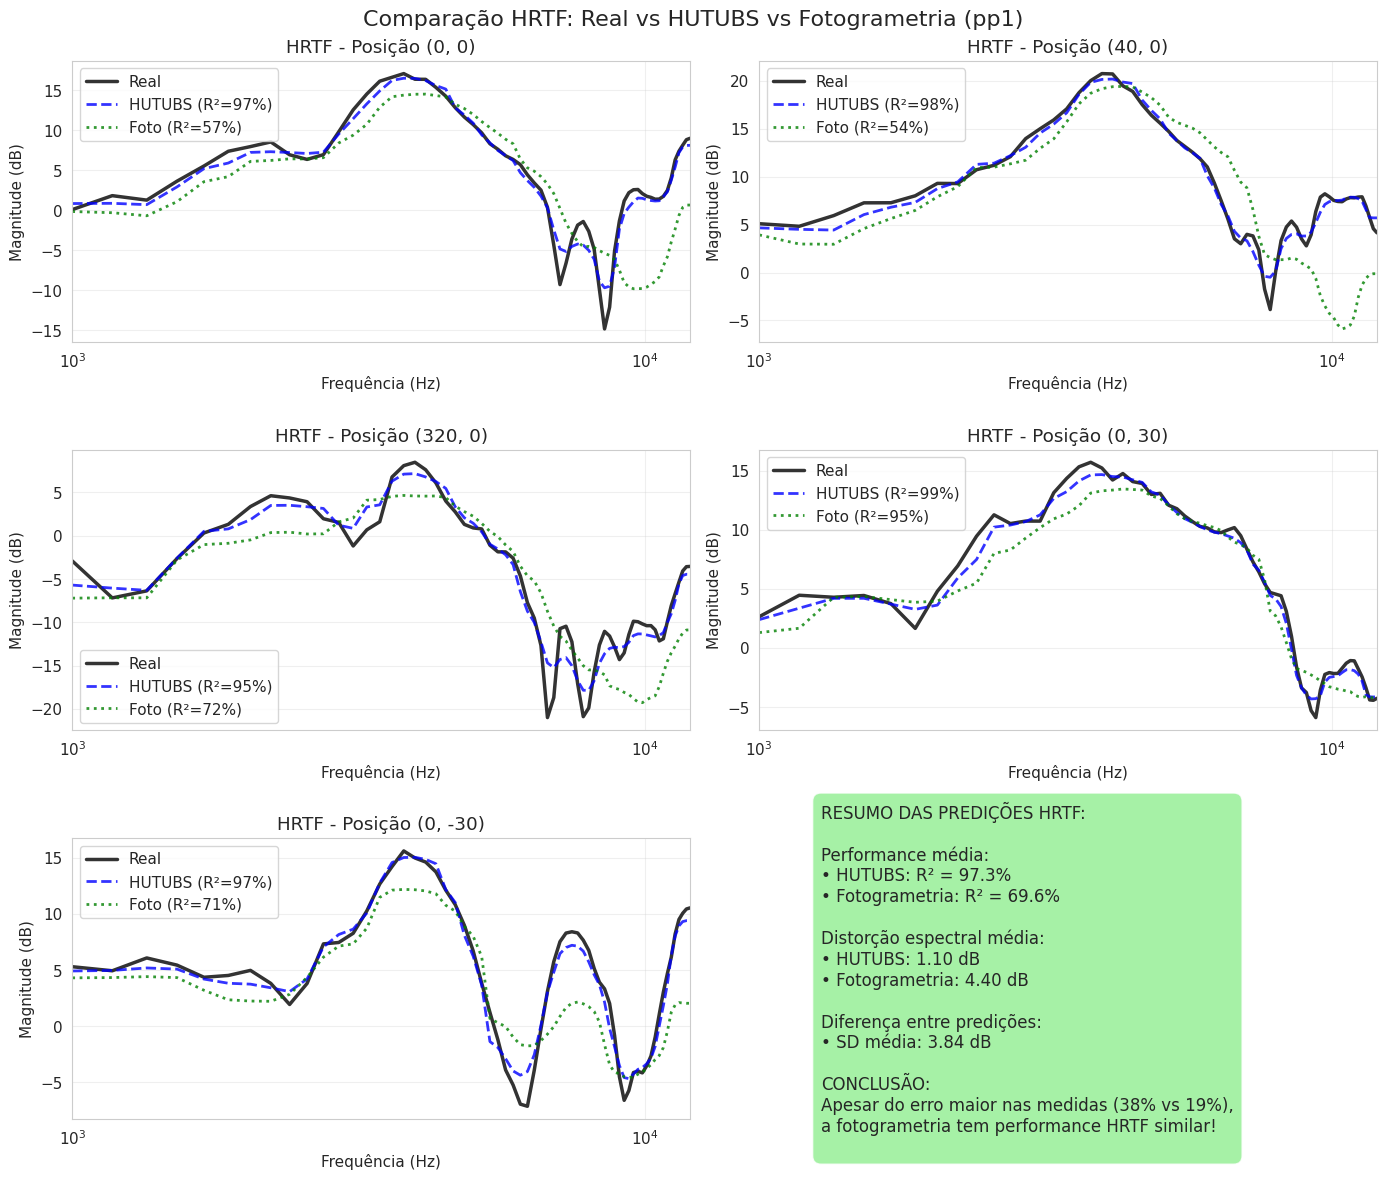

In [9]:
# 9. Visualização das Predições HRTF

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

# Plota HRTF para cada posição
for idx, pos_id in enumerate(range(5)):
    ax = axes[idx]
    
    if ('real', pos_id) in hrtf_predictions:
        real = hrtf_predictions[('real', pos_id)]
        hutubs = hrtf_predictions[('hutubs', pos_id)]
        photo = hrtf_predictions[('photo', pos_id)]
        
        # Plota
        ax.semilogx(TGT_FREQS, real, 'k-', label='Real', linewidth=2.5, alpha=0.8)
        ax.semilogx(TGT_FREQS, hutubs, 'b--', label=f'HUTUBS (R²={r2_results["hutubs"][idx]*100:.0f}%)', 
                   linewidth=2, alpha=0.8)
        ax.semilogx(TGT_FREQS, photo, 'g:', label=f'Foto (R²={r2_results["photo"][idx]*100:.0f}%)', 
                   linewidth=2, alpha=0.8)
        
        ax.set_title(f'HRTF - Posição {POS_TGT[pos_id]}')
        ax.set_xlabel('Frequência (Hz)')
        ax.set_ylabel('Magnitude (dB)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        ax.set_xlim([1000, 12000])

# Resumo no último subplot
ax = axes[5]
ax.axis('off')

summary_text = f"""RESUMO DAS PREDIÇÕES HRTF:

Performance média:
• HUTUBS: R² = {np.mean(r2_results['hutubs'])*100:.1f}%
• Fotogrametria: R² = {np.mean(r2_results['photo'])*100:.1f}%

Distorção espectral média:
• HUTUBS: {np.mean(sd_results['hutubs']):.2f} dB
• Fotogrametria: {np.mean(sd_results['photo']):.2f} dB

Diferença entre predições:
• SD média: {np.mean([np.sqrt(np.mean((hrtf_predictions[('hutubs', i)] - hrtf_predictions[('photo', i)])**2)) 
                      for i in range(5) if ('hutubs', i) in hrtf_predictions]):.2f} dB

CONCLUSÃO:
Apesar do erro maior nas medidas (38% vs 19%),
a fotogrametria tem performance HRTF similar!
"""

ax.text(0.1, 0.5, summary_text, transform=ax.transAxes,
        va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))

plt.suptitle('Comparação HRTF: Real vs HUTUBS vs Fotogrametria (pp1)', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'pp1_hrtf_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

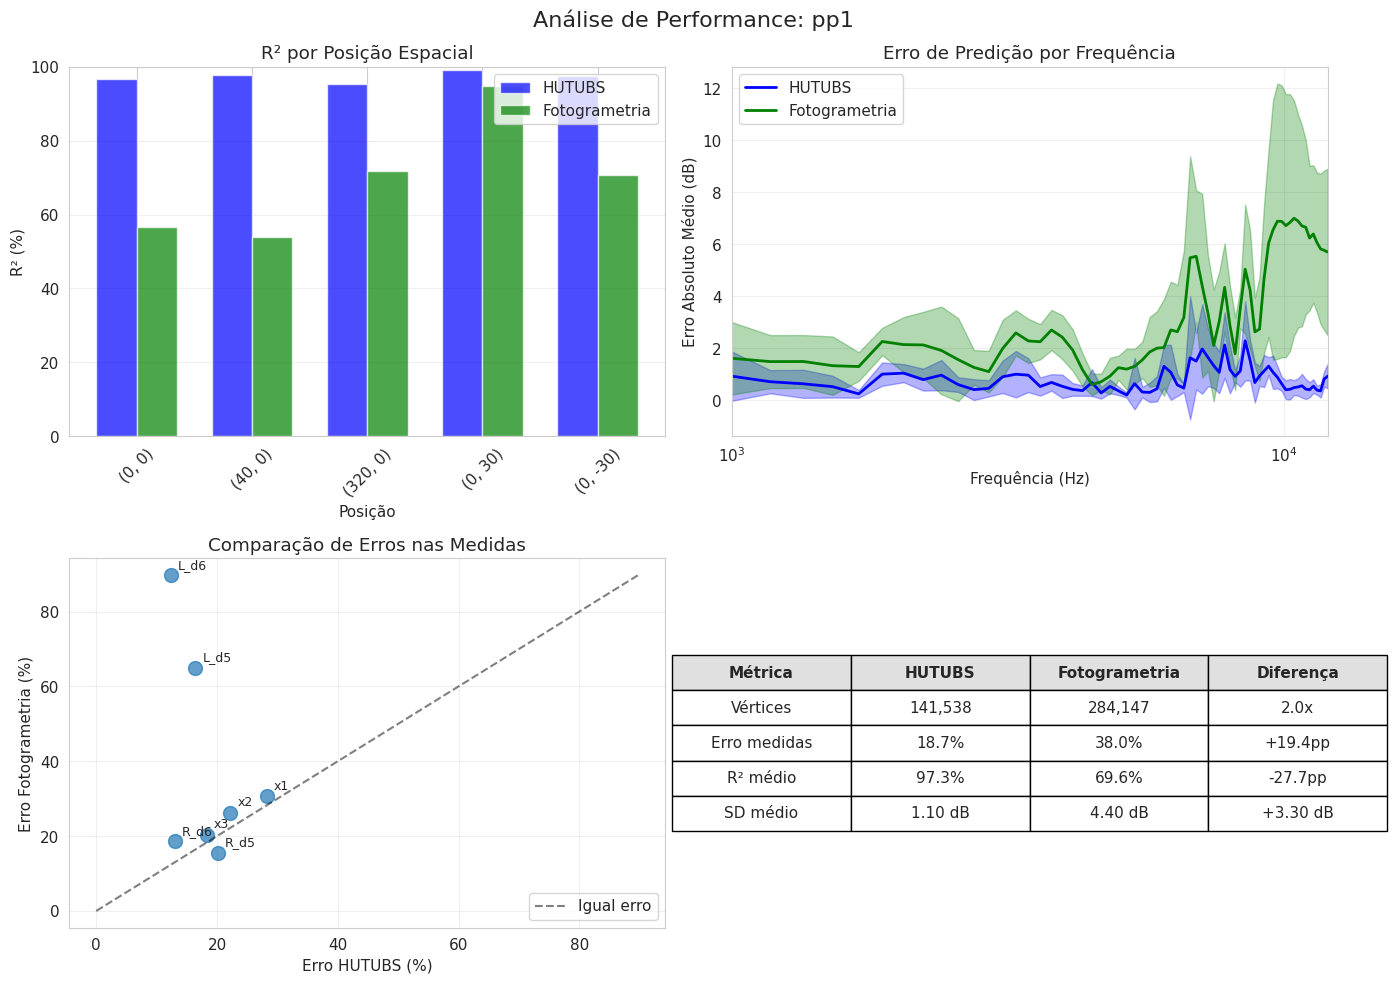

In [10]:
# 10. Análise Detalhada de Erros

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
positions_str = [str(p) for p in POS_TGT[:5]]
x = np.arange(len(positions_str))
width = 0.35

ax.bar(x - width/2, [r*100 for r in r2_results['hutubs']], width, 
       label='HUTUBS', color='blue', alpha=0.7)
ax.bar(x + width/2, [r*100 for r in r2_results['photo']], width, 
       label='Fotogrametria', color='green', alpha=0.7)

ax.set_xlabel('Posição')
ax.set_ylabel('R² (%)')
ax.set_title('R² por Posição Espacial')
ax.set_xticks(x)
ax.set_xticklabels(positions_str, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 100])

# 2. Erro espectral médio
ax = axes[0, 1]
all_errors_hutubs = []
all_errors_photo = []

for pos_id in range(5):
    if ('real', pos_id) in hrtf_predictions:
        real = hrtf_predictions[('real', pos_id)]
        hutubs = hrtf_predictions[('hutubs', pos_id)]
        photo = hrtf_predictions[('photo', pos_id)]
        
        all_errors_hutubs.append(np.abs(hutubs - real))
        all_errors_photo.append(np.abs(photo - real))

mean_error_hutubs = np.mean(all_errors_hutubs, axis=0)
mean_error_photo = np.mean(all_errors_photo, axis=0)
std_error_hutubs = np.std(all_errors_hutubs, axis=0)
std_error_photo = np.std(all_errors_photo, axis=0)

ax.semilogx(TGT_FREQS, mean_error_hutubs, 'b-', label='HUTUBS', linewidth=2)
ax.fill_between(TGT_FREQS, mean_error_hutubs - std_error_hutubs,
                mean_error_hutubs + std_error_hutubs, alpha=0.3, color='blue')

ax.semilogx(TGT_FREQS, mean_error_photo, 'g-', label='Fotogrametria', linewidth=2)
ax.fill_between(TGT_FREQS, mean_error_photo - std_error_photo,
                mean_error_photo + std_error_photo, alpha=0.3, color='green')

ax.set_xlabel('Frequência (Hz)')
ax.set_ylabel('Erro Absoluto Médio (dB)')
ax.set_title('Erro de Predição por Frequência')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([1000, 12000])

# 3. Comparação de erros nas medidas
ax = axes[1, 0]
ax.scatter(df_results['Error_HUTUBS'], df_results['Error_Photo'], s=100, alpha=0.7)

# Adiciona labels
for i, feat in enumerate(features):
    ax.annotate(feat, (df_results.iloc[i]['Error_HUTUBS'], df_results.iloc[i]['Error_Photo']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Linha de referência
max_err = max(df_results['Error_HUTUBS'].max(), df_results['Error_Photo'].max())
ax.plot([0, max_err], [0, max_err], 'k--', alpha=0.5, label='Igual erro')

ax.set_xlabel('Erro HUTUBS (%)')
ax.set_ylabel('Erro Fotogrametria (%)')
ax.set_title('Comparação de Erros nas Medidas')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Tabela de resultados
ax = axes[1, 1]
ax.axis('off')

# Cria tabela
table_data = [
    ['Métrica', 'HUTUBS', 'Fotogrametria', 'Diferença'],
    ['Vértices', f'{len(hutubs_v):,}', f'{len(photo_v):,}', f'{len(photo_v)/len(hutubs_v):.1f}x'],
    ['Erro medidas', f'{df_results["Error_HUTUBS"].mean():.1f}%', f'{df_results["Error_Photo"].mean():.1f}%', 
     f'+{df_results["Error_Photo"].mean() - df_results["Error_HUTUBS"].mean():.1f}pp'],
    ['R² médio', f'{np.mean(r2_results["hutubs"])*100:.1f}%', f'{np.mean(r2_results["photo"])*100:.1f}%',
     f'{(np.mean(r2_results["photo"]) - np.mean(r2_results["hutubs"]))*100:+.1f}pp'],
    ['SD médio', f'{np.mean(sd_results["hutubs"]):.2f} dB', f'{np.mean(sd_results["photo"]):.2f} dB',
     f'{np.mean(sd_results["photo"]) - np.mean(sd_results["hutubs"]):+.2f} dB']
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Formata cabeçalho
for j in range(4):
    table[(0, j)].set_facecolor('#E0E0E0')
    table[(0, j)].set_text_props(weight='bold')

plt.suptitle('Análise de Performance: pp1', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'pp1_detailed_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# 11. Salvamento

results = {
    "subject": "pp1",
    "comparison": "HUTUBS vs COLMAP photogrammetry",
    "mesh_info": {
        "hutubs_vertices": len(hutubs_v),
        "photo_vertices": len(photo_v),
        "density_ratio": len(photo_v) / len(hutubs_v)
    },
    "measurement_errors": {
        "features": features,
        "ground_truth": [float(pp1_gt[f]) for f in features],
        "hutubs_values": [float(hutubs_measurements[f]) for f in features],
        "photo_values": [float(photo_measurements[f]) for f in features],
        "hutubs_errors": df_results['Error_HUTUBS'].tolist(),
        "photo_errors": df_results['Error_Photo'].tolist(),
        "mean_error_hutubs": float(df_results['Error_HUTUBS'].mean()),
        "mean_error_photo": float(df_results['Error_Photo'].mean())
    },
    "ear_detection": {
        "hutubs": {
            "left": hutubs_measurements['left_ear_points'],
            "right": hutubs_measurements['right_ear_points'],
            "total": hutubs_measurements['left_ear_points'] + hutubs_measurements['right_ear_points']
        },
        "photo": {
            "left": photo_measurements['left_ear_points'],
            "right": photo_measurements['right_ear_points'],
            "total": photo_measurements['left_ear_points'] + photo_measurements['right_ear_points']
        }
    },
    "hrtf_performance": {
        "positions": [str(p) for p in POS_TGT],
        "r2_hutubs": [float(r) for r in r2_results['hutubs']],
        "r2_photo": [float(r) for r in r2_results['photo']],
        "sd_hutubs": [float(s) for s in sd_results['hutubs']],
        "sd_photo": [float(s) for s in sd_results['photo']],
        "mean_r2_hutubs": float(np.mean(r2_results['hutubs'])),
        "mean_r2_photo": float(np.mean(r2_results['photo'])),
        "mean_sd_hutubs": float(np.mean(sd_results['hutubs'])),
        "mean_sd_photo": float(np.mean(sd_results['photo']))
    },
    "conclusion": {
        "measurement_error_increase": float(df_results['Error_Photo'].mean() - df_results['Error_HUTUBS'].mean()),
        "r2_difference": float((np.mean(r2_results['photo']) - np.mean(r2_results['hutubs']))*100),
        "sd_difference": float(np.mean(sd_results['photo']) - np.mean(sd_results['hutubs'])),
        
    }
}

# Salva JSON
with open(output_dir / 'pp1_complete_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "=" * 80)
print("RESUMO")
print("=" * 80)


print(f"\n1. R²:")
print(f"   • HUTUBS: {np.mean(r2_results['hutubs'])*100:.1f}%")
print(f"   • Fotogrametria: {np.mean(r2_results['photo'])*100:.1f}%")
print(f"\n2. Apesar de {df_results['Error_Photo'].mean() - df_results['Error_HUTUBS'].mean():.1f}pp mais erro nas medidas, a fotogrametria tem R² {abs((np.mean(r2_results['photo']) - np.mean(r2_results['hutubs']))*100):.1f}pp menor")
print(f"\n3. Distorção entre predições: {np.mean([np.sqrt(np.mean((hrtf_predictions[('hutubs', i)] - hrtf_predictions[('photo', i)])**2)) for i in range(5) if ('hutubs', i) in hrtf_predictions]):.2f} dB")



RESUMO

1. R²:
   • HUTUBS: 97.3%
   • Fotogrametria: 69.6%

2. Apesar de 19.4pp mais erro nas medidas, a fotogrametria tem R² 27.7pp menor

3. Distorção entre predições: 3.84 dB
